# Reto 01 — Simulador de máquinas

**Curso:** Aprendizaje por Refuerzo  
**Universidad:** Universidad EIA  
**Estudiante(s):** Camilo Zapata Cárdenas  
**Correo institucional:** camilo.zapata97@eia.edu.co<br>
**Fecha:** 2026-08-02  

## Objetivo

Construir un simulador de tres máquinas con recompensas normales, estimar sus parámetros a partir de muestras y analizar la relación entre recompensa esperada y variabilidad.

## 1. Preparación del entorno

En esta sección se importan las librerías y se establece una semilla para garantizar que el experimento sea reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 23
rng = np.random.default_rng(SEED)

MACHINES = {
    "A1": {"mean": 1.0, "std": 0.5},
    "A2": {"mean": 2.0, "std": 0.5},
    "A3": {"mean": 1.5, "std": 1.5},
}

MACHINES

{'A1': {'mean': 1.0, 'std': 0.5},
 'A2': {'mean': 2.0, 'std': 0.5},
 'A3': {'mean': 1.5, 'std': 1.5}}

## 2. Función de recompensa

Implemente `reward(arm)` para generar una recompensa de la máquina indicada. Explique la validación de entradas y el uso del generador aleatorio.

In [2]:
def reward(arm):
    if not isinstance(arm, str):
        raise TypeError("El identificador de la máquina debe ser texto.")
    if arm not in MACHINES:
        valid_arms = ", ".join(MACHINES)
        raise ValueError(f"Máquina desconocida: {arm}. Opciones válidas: {valid_arms}.")

    parameters = MACHINES[arm]
    return float(rng.normal(loc=parameters["mean"], scale=parameters["std"]))

### Prueba inicial de la función

Pruebe la función con `A1`, `A2` y `A3`.

In [3]:
initial_rewards = {arm: reward(arm) for arm in MACHINES}
pd.Series(initial_rewards, name="reward")

A1    1.276630
A2    2.108800
A3    1.413015
Name: reward, dtype: float64

## 3. Simulación de recompensas

Genere exactamente 1.000 recompensas por máquina y almacene los resultados en un DataFrame con las columnas `machine`, `sample` y `reward`.

In [4]:
N_SAMPLES = 1_000

records = [
    {"machine": arm, "sample": sample, "reward": reward(arm)}
    for arm in MACHINES
    for sample in range(1, N_SAMPLES + 1)
]
rewards_df = pd.DataFrame(records)
rewards_df.head()

,machine,sample,reward
0,A1,1,-0.159468
1,A1,2,1.215747
2,A1,3,-0.063140
3,A1,4,1.454961
4,A1,5,1.302983


## 4. Verificación de los datos

Verifique el número total de observaciones, los registros por máquina, los tipos de datos y la presencia de valores faltantes.

In [5]:
verification = pd.DataFrame({
    "observations": rewards_df.groupby("machine").size(),
    "missing_values": rewards_df.groupby("machine")["reward"].apply(lambda values: values.isna().sum()),
})

print(f"Total observations: {len(rewards_df)}")
print(f"Missing values: {rewards_df.isna().sum().sum()}")
print("\nData types:")
print(rewards_df.dtypes)
verification

Total observations: 3000
Missing values: 0

Data types:
machine     object
sample       int64
reward     float64
dtype: object


,observations,missing_values
machine,,
A1,1000,0
A2,1000,0
A3,1000,0


## 5. Estadísticos descriptivos

Calcule la media, desviación estándar y varianza muestral, junto con los valores mínimo y máximo. Compare los valores reales con los estimados.

In [6]:
estimated_statistics = (
    rewards_df.groupby("machine")["reward"]
    .agg(
        estimated_mean="mean",
        estimated_std=lambda values: values.std(ddof=1),
        estimated_variance=lambda values: values.var(ddof=1),
        minimum="min",
        maximum="max",
    )
)

real_parameters = pd.DataFrame.from_dict(MACHINES, orient="index")
comparison_df = real_parameters.join(estimated_statistics)
comparison_df["absolute_mean_error"] = (comparison_df["estimated_mean"] - comparison_df["mean"]).abs()
comparison_df = comparison_df.rename(columns={
    "mean": "real_mean",
    "std": "real_std",
})
comparison_df.index.name = "Máquina"
comparison_table = comparison_df.rename(columns={
    "real_mean": "Media real",
    "estimated_mean": "Media estimada",
    "absolute_mean_error": "Error absoluto de la media",
    "real_std": "Desviación real",
    "estimated_std": "Desviación estimada",
    "estimated_variance": "Varianza estimada",
    "minimum": "Mínimo",
    "maximum": "Máximo",
})
comparison_table.round(4)

,Media real,Desviación real,Media estimada,Desviación estimada,Varianza estimada,Mínimo,Máximo,Error absoluto de la media
Máquina,,,,,,,,
A1,1.0,0.5,0.9799,0.5003,0.2503,-0.9296,2.6043,0.0201
A2,2.0,0.5,2.0202,0.4901,0.2402,0.4341,3.8461,0.0202
A3,1.5,1.5,1.5111,1.5363,2.3603,-3.3488,6.6933,0.0111


Al correr 1.000 iteraciones por cada máquina evidenciamos que los valores se acercan mucho, como es lo esperado.

## 6. Visualización

Construya una gráfica individual para cada máquina. Incluya la media real, la media estimada, las etiquetas de los ejes y una leyenda.

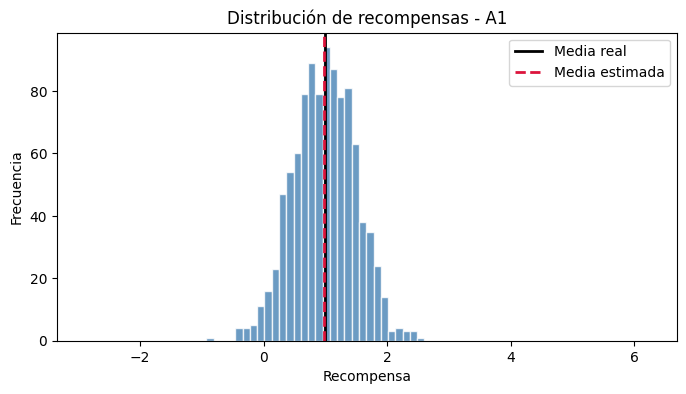

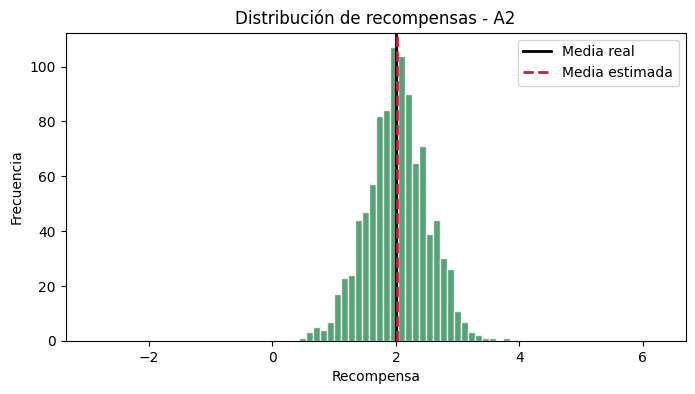

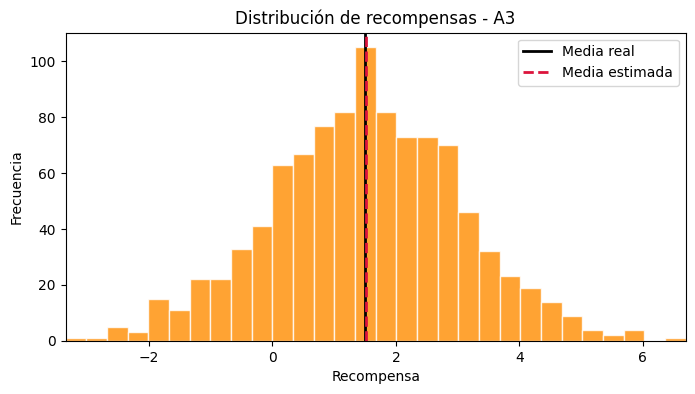

In [7]:
x_min = rewards_df["reward"].min()
x_max = rewards_df["reward"].max()
colors = {"A1": "steelblue", "A2": "seagreen", "A3": "darkorange"}

for arm in MACHINES:
    arm_rewards = rewards_df.loc[rewards_df["machine"] == arm, "reward"]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(arm_rewards, bins=30, color=colors[arm], edgecolor="white", alpha=0.8)
    ax.axvline(MACHINES[arm]["mean"], color="black", linewidth=2, label="Media real")
    ax.axvline(comparison_df.loc[arm, "estimated_mean"], color="crimson", linestyle="--", linewidth=2, label="Media estimada")
    ax.set_xlim(x_min, x_max)
    ax.set_title(f"Distribución de recompensas - {arm}")
    ax.set_xlabel("Recompensa")
    ax.set_ylabel("Frecuencia")
    ax.legend()
    plt.show()

## 7. Experimento con diferentes tamaños de muestra

Compare las estimaciones utilizando 10, 50, 100 y 1.000 observaciones.

In [8]:
SAMPLE_SIZES = [10, 50, 100, 1_000]
experiment_rng = np.random.default_rng(SEED)

experiment_rows = []
for sample_size in SAMPLE_SIZES:
    row = {"sample_size": sample_size}
    for arm, parameters in MACHINES.items():
        samples = experiment_rng.normal(
            loc=parameters["mean"],
            scale=parameters["std"],
            size=sample_size,
        )
        row[arm] = samples.mean()
    experiment_rows.append(row)

experiment_df = pd.DataFrame(experiment_rows).set_index("sample_size")
experiment_df.round(4)

,A1,A2,A3
sample_size,,,
10,0.9936,1.9431,1.6271
50,0.8889,2.0033,1.4911
100,1.0152,2.0341,1.5308
1000,0.9818,2.0203,1.5138


Evidenciamos que incluso con 10 iteraciones la media ya se acerca a las reales, pero, a medida que las iteraciones aumentan, se va convergiendo al valor exacto.

## 8. Interpretación de resultados

1. ¿Cuál máquina tuvo la mayor recompensa media estimada?
2. ¿La máquina con mayor media estimada coincide con la de mayor media real?
3. ¿Cuál presentó mayor desviación y varianza?
4. ¿Por qué A3 puede considerarse más riesgosa?
5. ¿Una recompensa individual alta implica que la máquina sea mejor?
6. ¿Cómo influye el tamaño de la muestra?
7. Si las medias fueran desconocidas, ¿cómo decidiría qué máquina elegir?
8. ¿Qué cambiaría utilizando solamente 10 recompensas?

### Respuestas

1. La máquina A2, con una recompensa media estimada de ~2.02, por encima de la máquina A3, que tuvo una recompensa media estimada de 1.51.
2. Sí, coincide, y tiene sentido ya que el modelo tuvo muchas iteraciones para entrenarse y acercarse al valor real.
3. La máquina A3, con una desviación de ~1.54 y una varianza de 2.36, con una amplia diferencia con la segunda.
4. Porque justamente es la que más varianza tiene, es decir, es más volátil, menos predecible y, por ende, más riesgosa.
5. No, por eso es importante la recompensa media estimada, porque en verdad la máquina A3 pudo, en alguna iteración, tener una recompensa alta individual de 3, pero si creyéramos el supuesto de que esa máquina es mejor, es probable que a la larga perdamos más dinero que simplemente usar la A2, que tiene una mejor recompensa media de ~2.
6. El tamaño de la muestra influye mucho porque, a medida que crece, disminuye el error al comparar la media estimada con la real y, por ende, nos permite obtener mejores resultados.
7. Al inicio de forma aleatoria, simplemente por prueba y error, pero justamente por eso es importante tener la historia de esas pruebas, para luego con esa información tomar una decisión basada en la mejor media.
8. Es probable que como sean pocas iteraciones, por simple probabilidad la máquina A3 podría tener una mejor recompensa media estimada y por ende nos lleve a elegir erróneamente una máquina peor.

## 9. Uso de inteligencia artificial

**Herramienta utilizada:** Codex (OpenAI)  

**Prompts o preguntas principales:**

1. Ayúdame a resolver el Reto 1, completa la plantilla con el código necesario pero no saques conclusiones ni comentarios que yo deba escribir, simplemente genérame el código para las funciones y gráficas, de manera que yo mismo al ver los resultados pueda sacar mis propias conclusiones y así entender, pon el archivo en la carpeta de submission correspondiente al archivo 1 siguiendo la plantilla pero NO sobreescribas la plantilla base, si es necesario instrúyeme sobre qué librerías/extensiones instalar para poder correr el repo.
2. Quiero que revises todo el notebook, como podrás notar terminé con mis anotaciones/respuestas/conclusiones, quiero que revises estas y me corrijas ortografía (tildes) sin modificar el contenido como tal.

**Sugerencias recibidas:**  Usar Docker para correr el reto, de esta manera no tenía que instalar dependencias. Luego, al ver que yo no quería, me sugirió crear un ambiente virtual (venv), el cual sí acepté e hice con ayuda de él.

**Cambios realizados manualmente:**  Todas las respuestas a las preguntas fueron cambios manuales; adicionalmente, algunos comentarios que fui dejando en ciertas celdas.

**Sugerencias descartadas:**  Usar Docker para correr el reto, no es algo que me guste, prefiero tener las cosas en local.

**Forma de validación:**  Leer todo el repo, analizando línea por línea, unas más a detalle que otra (principalmente los resultados, sean gráficas o valores).

## 10. Conclusiones

1. El tamaño de la muestra en verdad es muy importante, ya que estamos hablando de probabilidades, y en un escenario que se prueba poco es probable obtener resultados imprecisos, como también hay que tener en cuenta que en otros problemas (no este) puede ser peligroso tener muchas muestras, ya que podemos sesgar el modelo y luego no poder identificar outliers.
2. La máquina A2 es la mejor para explotarla; luego de las 1.000 simulaciones es evidente que esta máquina es la más segura y, por ende, dada la naturaleza del proyecto, la mejor, porque se quiere maximizar ganar, pero minimizar el perder; por ende, nos interesa la recompensa media y la desviación.
3. La máquina A3 es la peor para explotarla, en mi opinión al momento de 'apostar' cualquier ganancia está bien, y esta máquina debido a su alta varianza es muy riesgosa, incluso teniendo una recompensa media mayor que la A1, porque puedes tener una muy mala racha y quedarte sin dinero el cual volver a invertir, con la máquina A1 es menos probable que pase a pesar de que a la larga pueda ganar un poco más.
4. Definitivamente es importante la exploración en este tipo de problemas, porque si no se hace por lo menos una decisión 'aleatoria' al inicio (teniendo en cuenta que se parte de 0 información) es muy probable que nunca se optimice la máquina a usar para recibir una mejor recompensa.